In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt

 # change this later to try other records
RECORD = "100"

record = wfdb.rdrecord(RECORD, pn_dir="mitdb")
# sampling rate (samples per second)
fs = record.fs
# lead MLII as one long array
ecg = record.p_signal[:, 0]

print("Record:", RECORD)
print("Lead:", record.sig_name[0])
print("Sampling rate:", fs, "Hz")
print("Number of samples:", len(ecg))
print("Minutes:", len(ecg) / fs / 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00
Record: 100
Lead: MLII
Sampling rate: 360 Hz
Number of samples: 650000
Minutes: 30.092592592592595


In [ ]:
C = 1440   # how many samples we show (4 seconds - 360 samples per second)
H = 360    # how many samples we want to guess (1 second - 360 samples)

start = 5000
past = ecg[start : start + C]
future = ecg[start + C : start + C + H]

print(len(past), len(future))

1440 360


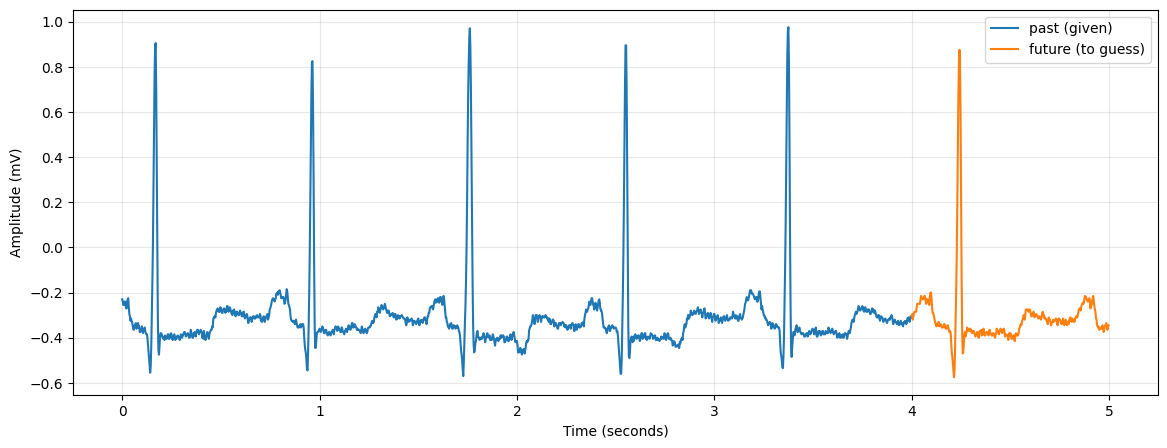

In [ ]:
t_past = np.arange(C) / fs
t_future = np.arange(C, C + H) / fs

plt.figure(figsize=(14, 5))
plt.plot(t_past, past, label="past (given)")
plt.plot(t_future, future, label="future (to guess)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

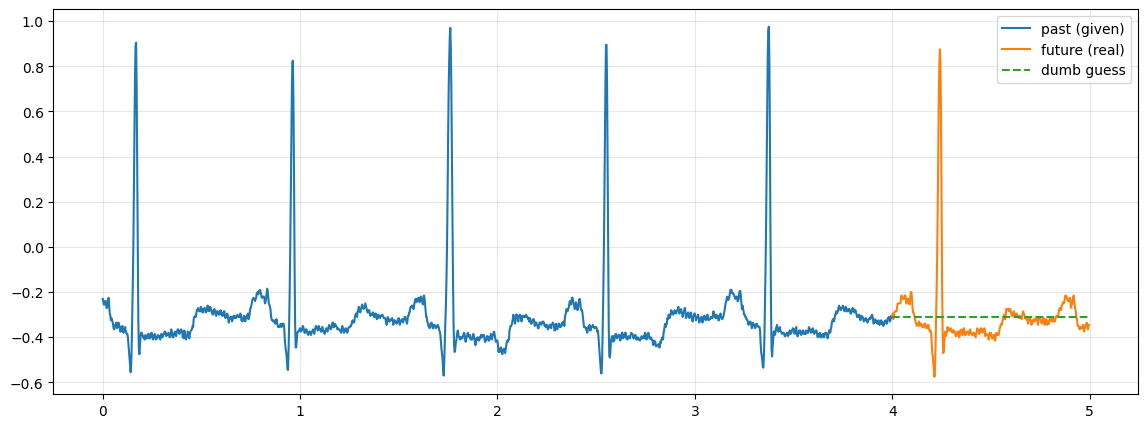

Average error (mV): 0.06941666666666667


In [ ]:
guess = np.full(H, past[-1])

plt.figure(figsize=(14, 5))
plt.plot(t_past, past, label="past (given)")
plt.plot(t_future, future, label="future (real)")
plt.plot(t_future, guess, label="dumb guess", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

error = np.mean(np.abs(future - guess))
print("Average error (mV):", error)

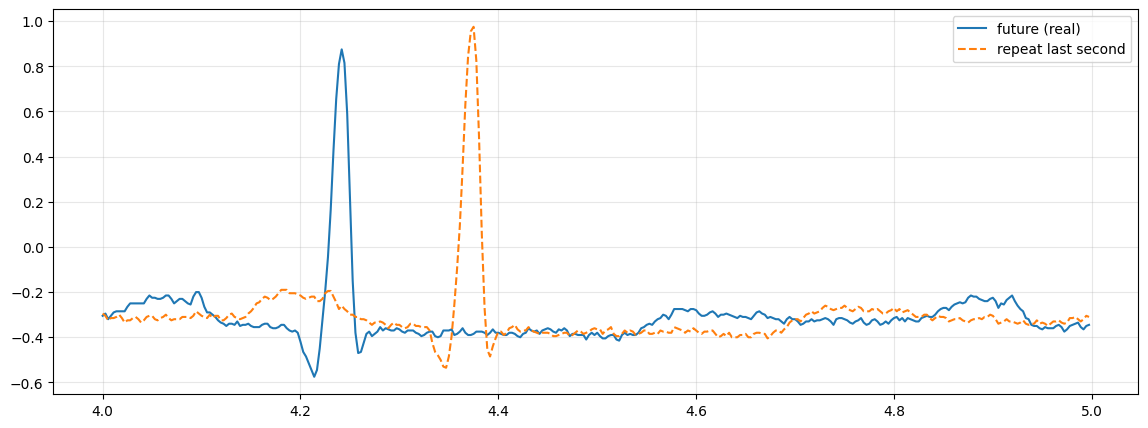

Repeat-last-second error (mV): 0.09894444444444443


In [ ]:
guess2 = past[-H:]   # the last 360 numbers(second) of the past
plt.figure(figsize=(14, 5))
plt.plot(t_future, future, label="future (real)")
plt.plot(t_future, guess2, label="repeat last second", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

error2 = np.mean(np.abs(future - guess2))
print("Repeat-last-second error (mV):", error2)

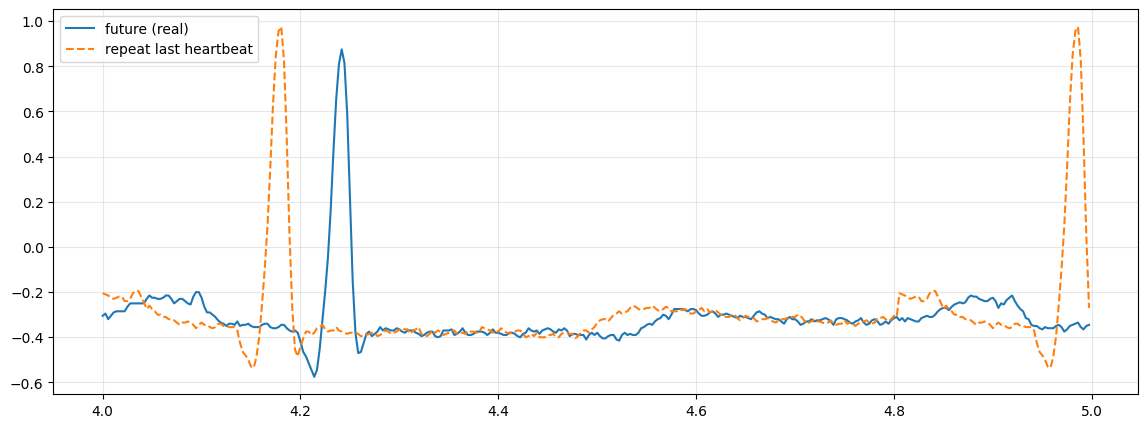

Repeat-last-heartbeat error (mV): 0.11404166666666667


In [ ]:
# Trying one heart beat:
P = 290   # one heartbeat length in samples (about 0.8 seconds)

guess3 = np.tile(past[-P:], 2)[:H]   # repeat the last heartbeat, cut to 360 numbers
error3 = np.mean(np.abs(future - guess3))

plt.figure(figsize=(14, 5))
plt.plot(t_future, future, label="future (real)")
plt.plot(t_future, guess3, label="repeat last heartbeat", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Repeat-last-heartbeat error (mV):", error3)

In [ ]:
for P in [280, 290, 300, 310]:
    g = np.tile(past[-P:], 2)[:H]
    print(P, np.mean(np.abs(future - g)))

280 0.11751388888888886
290 0.11404166666666667
300 0.07533333333333334
310 0.041666666666666664


In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(past, height=0.5, distance=100)
# positions of the spikes inside the blue part
print(peaks)
# gaps between consecutive spikes, in samples
print(np.diff(peaks))

[  61  347  634  918 1215]
[286 287 284 297]


P from the past: 297


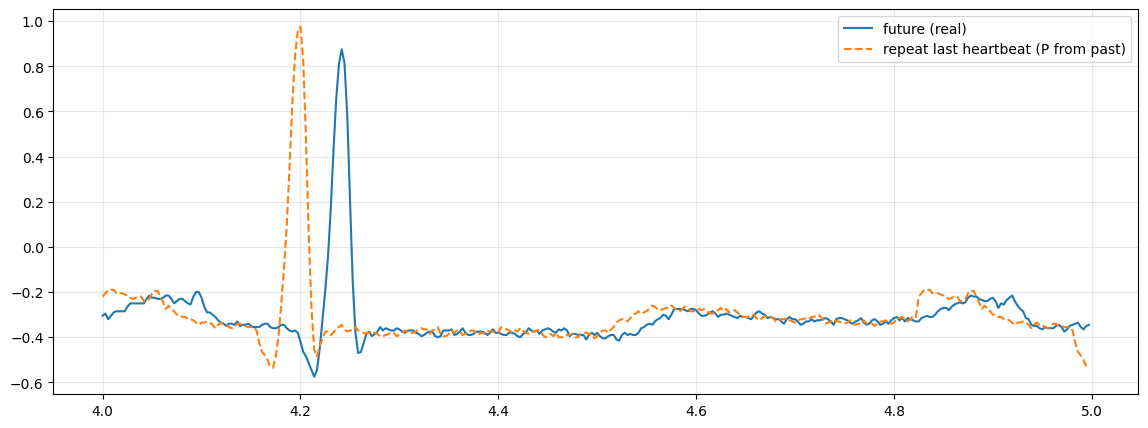

Fair repeat-last-heartbeat error (mV): 0.08154166666666667


In [ ]:
# last gap measured from the PAST only
P = np.diff(peaks)[-1]
print("P from the past:", P)

guess4 = np.tile(past[-P:], 2)[:H]
error4 = np.mean(np.abs(future - guess4))

plt.figure(figsize=(14, 5))
plt.plot(t_future, future, label="future (real)")
plt.plot(t_future, guess4, label="repeat last heartbeat (P from past)", linestyle="--")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("Fair repeat-last-heartbeat error (mV):", error4)

In [ ]:
split = int(0.8 * len(ecg))   # sample where the last 20% begins
test_zone = ecg[split:]

print("Test zone starts at sample:", split)
print("Test zone length:", len(test_zone))
print("That's about", len(test_zone) / fs / 60, "minutes")

Test zone starts at sample: 520000
Test zone length: 130000
That's about 6.018518518518518 minutes


In [ ]:
errors_flat = []

for start in range(0, len(test_zone) - C - H, H):
    past = test_zone[start : start + C]
    future = test_zone[start + C : start + C + H]
    guess = np.full(H, past[-1])
    errors_flat.append(np.mean(np.abs(future - guess)))

print("Number of windows:", len(errors_flat))
print("Average error (mV):", np.mean(errors_flat))

Number of windows: 357
Average error (mV): 0.1192069716775599


In [ ]:
from scipy.signal import find_peaks

errors_flat = []
errors_beat = []
fallbacks = 0   # how many times we couldn't find 2 heartbeats

for start in range(0, len(test_zone) - C - H, H):
    past = test_zone[start : start + C]
    future = test_zone[start + C : start + C + H]

    # Method 1: flat line
    guess_flat = np.full(H, past[-1])
    errors_flat.append(np.mean(np.abs(future - guess_flat)))

    # Method 2: repeat last heartbeat (P measured from the past only)
    peaks, _ = find_peaks(past, height=0.5, distance=100)
    if len(peaks) >= 2:
        P = np.diff(peaks)[-1]
        reps = H // P + 1                       # how many copies we need
        guess_beat = np.tile(past[-P:], reps)[:H]
    else:
        guess_beat = guess_flat                 # fallback if no heartbeats found
        fallbacks += 1
    errors_beat.append(np.mean(np.abs(future - guess_beat)))

print("Windows:", len(errors_flat))
print("Flat line average error:", np.mean(errors_flat))
print("Repeat-heartbeat average error:", np.mean(errors_beat))
print("Windows where peak finding failed:", fallbacks)

Windows: 357
Flat line average error: 0.1192069716775599
Repeat-heartbeat average error: 0.11125319016495487
Windows where peak finding failed: 0


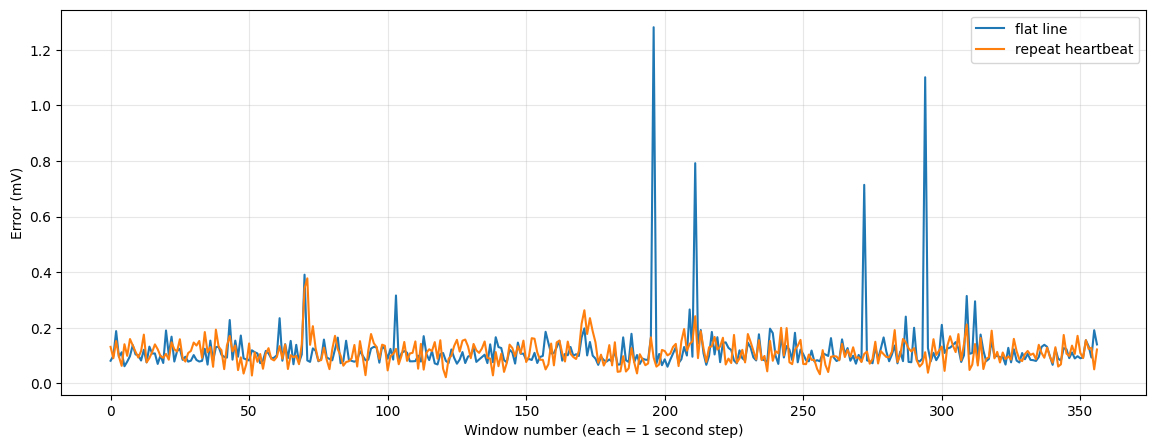

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(errors_flat, label="flat line")
plt.plot(errors_beat, label="repeat heartbeat")
plt.xlabel("Window number (each = 1 second step)")
plt.ylabel("Error (mV)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

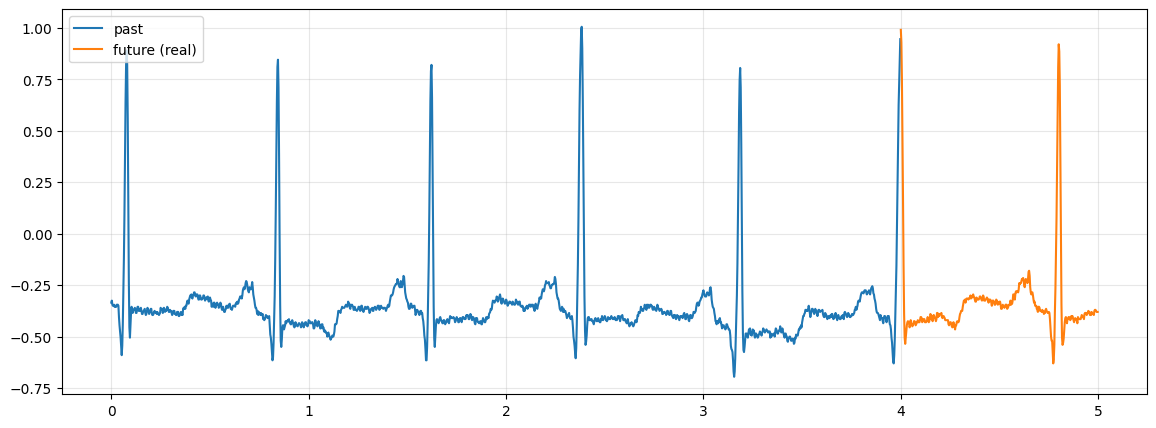

In [ ]:
# the window number with the big blue spike
w = 196
start = w * H
past = test_zone[start : start + C]
future = test_zone[start + C : start + C + H]

plt.figure(figsize=(14, 5))
plt.plot(np.arange(C) / fs, past, label="past")
plt.plot(np.arange(C, C + H) / fs, future, label="future (real)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from scipy.signal import find_peaks

# find every heartbeat spike in the whole test zone, once
peaks_all, _ = find_peaks(test_zone, height=0.5, distance=100)

# for each window, count how many spikes land inside its hidden second
spike_counts = []
for i in range(len(errors_flat)):
    a = i * H + C        # where this window's hidden second starts
    b = a + H            # where it ends
    spike_counts.append(np.sum((peaks_all >= a) & (peaks_all < b)))

spike_counts = np.array(spike_counts)
flat_arr = np.array(errors_flat)
beat_arr = np.array(errors_beat)

# average error for windows with 0 spikes, 1 spike, 2 spikes
for k in np.unique(spike_counts):
    mask = spike_counts == k
    print(k, "spikes:", mask.sum(), "windows | flat:", flat_arr[mask].mean(), "| beat:", beat_arr[mask].mean())

1 spikes: 262 windows | flat: 0.09904362807463953 | beat: 0.10107591178965225
2 spikes: 95 windows | flat: 0.174815350877193 | beat: 0.13932105263157896


In [ ]:
train_zone = ecg[:split]   # first 80%, the only part used for the scale

def naive_scale(x, s):
    # average |value now - value s steps ago|
    return np.mean(np.abs(x[s:] - x[:-s]))

for s in [1, 360]:
    scale = naive_scale(train_zone, s)
    print("s =", s, "| scale:", scale)
    print("   flat MASE:", np.mean(errors_flat) / scale)
    print("   beat MASE:", np.mean(errors_beat) / scale)

s = 1 | scale: 0.019434162373389186
   flat MASE: 6.133887809890261
   beat MASE: 5.724619771485067
s = 360 | scale: 0.14046477368947735
   flat MASE: 0.8486609741819565
   beat MASE: 0.7920362325923798
